# Tier 3: Discriminative ML, Centralized (Logistic Regression)

**CSCI 575 | Privacy-Preserving Record Linkage**

A discriminative linear classifier, logistic regression, trained centrally on the same 8 per-field similarity features. The trainer sees every record and every label. This is the discriminative-ML accuracy reference point that the federated tiers (T4, T5) are measured against.

In [1]:
import pandas as pd
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split

from utils import (
    FEATURE_NAMES,
    load_candidates, build_feature_matrix,
    compute_metrics, print_metrics, save_metrics,
    plot_score_distribution,
    save_example_pair_predictions,
)

THRESHOLD = 0.50

## Load Data and Build Feature Matrix

In [2]:
candidates              = load_candidates()
field_similarity_scores = build_feature_matrix(candidates)

print(f'{len(candidates):,} candidate pairs  '
      f'({candidates["is_match"].sum():,} matches, '
      f'{(~candidates["is_match"]).sum():,} non-matches)')

500,000 candidate pairs  (50,000 matches, 450,000 non-matches)


## Train the Model

80/20 stratified split, `random_state=42` (reused in every tier). 

Coefficients play the role of Tier 1's hand-tuned `FIELD_WEIGHTS`, except are learned from the labels.

In [3]:
labels = candidates['is_match'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    field_similarity_scores,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels,
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

learned_coefficients = pd.Series(model.coef_[0], index=FEATURE_NAMES).sort_values(ascending=False)

print('Learned coefficients (sorted by value):')
print(learned_coefficients.round(3).to_string())

Learned coefficients (sorted by value):
date_of_birth     14.683
zip_code          10.006
phone              9.549
state              9.208
first_name         5.773
last_name          5.765
street_address     5.603
email              2.150


## Predict on All Candidates

Probabilities for every pair so the comparison notebook can look up the example pairs. Metrics use only the 20% test split.

In [4]:
candidates['match_probability'] = model.predict_proba(field_similarity_scores)[:, 1]
candidates['predicted_match']   = (candidates['match_probability'] >= THRESHOLD).astype(int)

test_candidates = candidates.loc[X_test.index]

(test_candidates[['rec_id_a', 'rec_id_b', 'is_match', 'match_probability', 'predicted_match']]
    .round({'match_probability': 3})
    .head())

,rec_id_a,rec_id_b,is_match,match_probability,predicted_match
84492,16243,45003,False,0.000,0
282042,4223,18009,False,0.000,0
478886,21025,48009,False,0.000,0
263682,40414,32578,False,0.000,0
43310,43310,43310,True,0.815,1


## Evaluate

Same four metrics as the other tiers, on the 100k test set.

In [5]:
metrics = compute_metrics(
    tier_name        = 'T3_centralized_ml',
    true_labels      = test_candidates['is_match'].astype(int),
    predicted_labels = test_candidates['predicted_match'],
    scores           = test_candidates['match_probability'],
    threshold        = THRESHOLD,
    n_pairs          = len(test_candidates),
)
print_metrics(metrics)

Precision : 0.9993
Recall    : 0.9978
F1        : 0.9985
AUC-ROC   : 1.0000
Threshold : 0.5
N pairs   : 100,000


## Probability Distribution

Histogram of predicted match probabilities on the test set, split by ground-truth label. The learned boundary separates the two populations more cleanly than Tier 1's hand-tuned score.

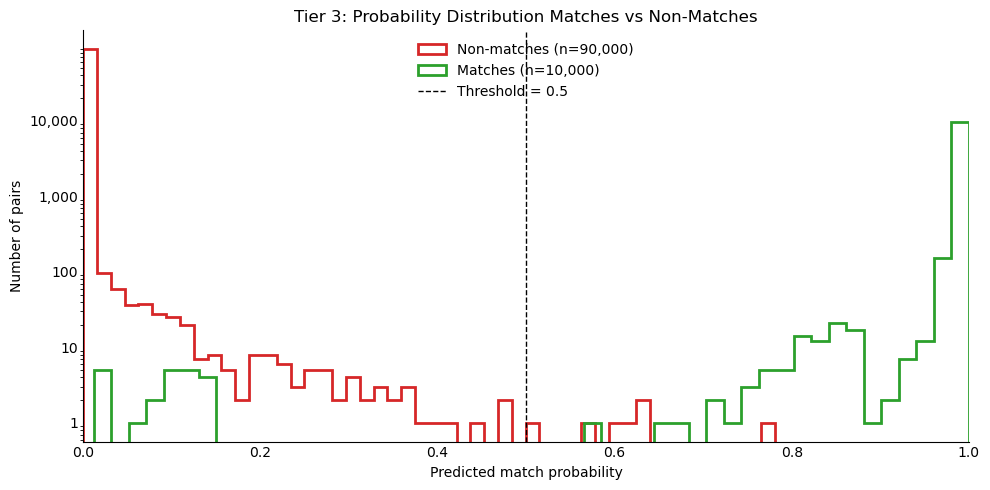

In [6]:
plot_score_distribution(
    match_scores     = test_candidates.loc[test_candidates['is_match'],  'match_probability'],
    non_match_scores = test_candidates.loc[~test_candidates['is_match'], 'match_probability'],
    threshold        = THRESHOLD,
    title            = 'Tier 3: Probability Distribution Matches vs Non-Matches',
    x_label          = 'Predicted match probability',
    filename         = 'tier3_score_distribution.png',
)

## Save Results

In [7]:
save_metrics(metrics, 'tier3_metrics.csv')
save_example_pair_predictions(candidates, 'T3_centralized_ml', 'match_probability', 'tier3_example_predictions.csv')